# Transient signal detection based on ML and feature extraction (Tsfresh)

Main JupyterNotebook, it includes the generation of synthetic data, dataset feature extraction and other small applications.

## Libraries

In [1]:
import os
import pickle
import glob
import random
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed
from tsfresh import extract_features, select_features, defaults
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import ComprehensiveFCParameters
from tsfresh.feature_extraction.settings import from_columns
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn import ensemble
from sklearn.preprocessing import StandardScaler

import sys
import importlib
sys.path.append("/home/martin/Escritorio/PhD/sources/")

import toolbox as tb
import functions as fn
from xue_synthgen import MakeDataset, scale

importlib.reload(fn)

%matplotlib inline
plt.style.use('seaborn-v0_8-dark')

## Folders

In [2]:
# Directories for code outputs
prod = '/home/martin/Escritorio/PhD/database/latest_version/' # Main folder for files or products
img = prod + 'img/'                                           # Images

tb.CheckFolder(img)

Folder '/home/martin/Escritorio/PhD/database/latest_version/img/' already exists.


## Signal generation

In [10]:
# Defines generation of dataset
nt = 300                # Sample length
n_train_sample = 100000 # Number of samples

# Allocate data
train_data = np.zeros((n_train_sample, nt))
train_label = np.zeros((n_train_sample, nt))

# Iteration for dataset
for i in tqdm(range(n_train_sample), mininterval=1):
    train_data[i,:], train_label[i,:] = MakeDataset(nt, event_num=[0,1], noise_type=i%3, label_snr_threshold=1)  
train_data = scale(train_data) # Scaling

  0%|          | 0/100000 [00:00<?, ?it/s]

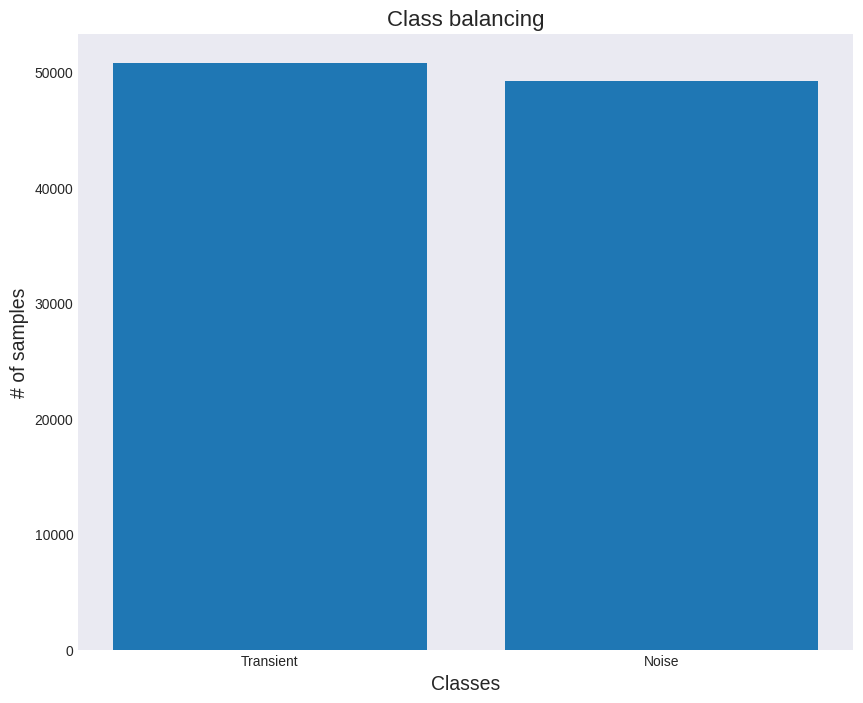

In [6]:
# Estimate balancing of classes (make sure its not too unbalanced)
label = np.zeros(n_train_sample)
for i in range(n_train_sample):
    if 1.0 in train_label[i]:
        label[i] = 1 # Transient
    else:
        label[i] = 0 # Noise
        
h = np.array([label.sum(), len(label)-label.sum()])
x = ['Transient', 'Noise']

# Plot
plt.figure(figsize=(10,8))
plt.bar(x, h)
plt.ylabel("# of samples", fontsize=14)
plt.xlabel("Classes", fontsize=14)
plt.title("Class balancing", fontsize=16)
plt.show()

In [6]:
# Data to DataFrame
#train_df = pd.DataFrame(train_data)
#label_df = pd.DataFrame(train_label)

# Save and load data (just in case)
#train_df.to_hdf(prod + 'train_data.h5', key='key',complevel=9)
#label_df.to_hdf(prod + 'train_label.h5', key='key',complevel=9)

train_data  = pd.read_hdf(prod+'train_data.h5', key='key').to_numpy()
train_label = pd.read_hdf(prod+'train_label.h5', key='key').to_numpy()

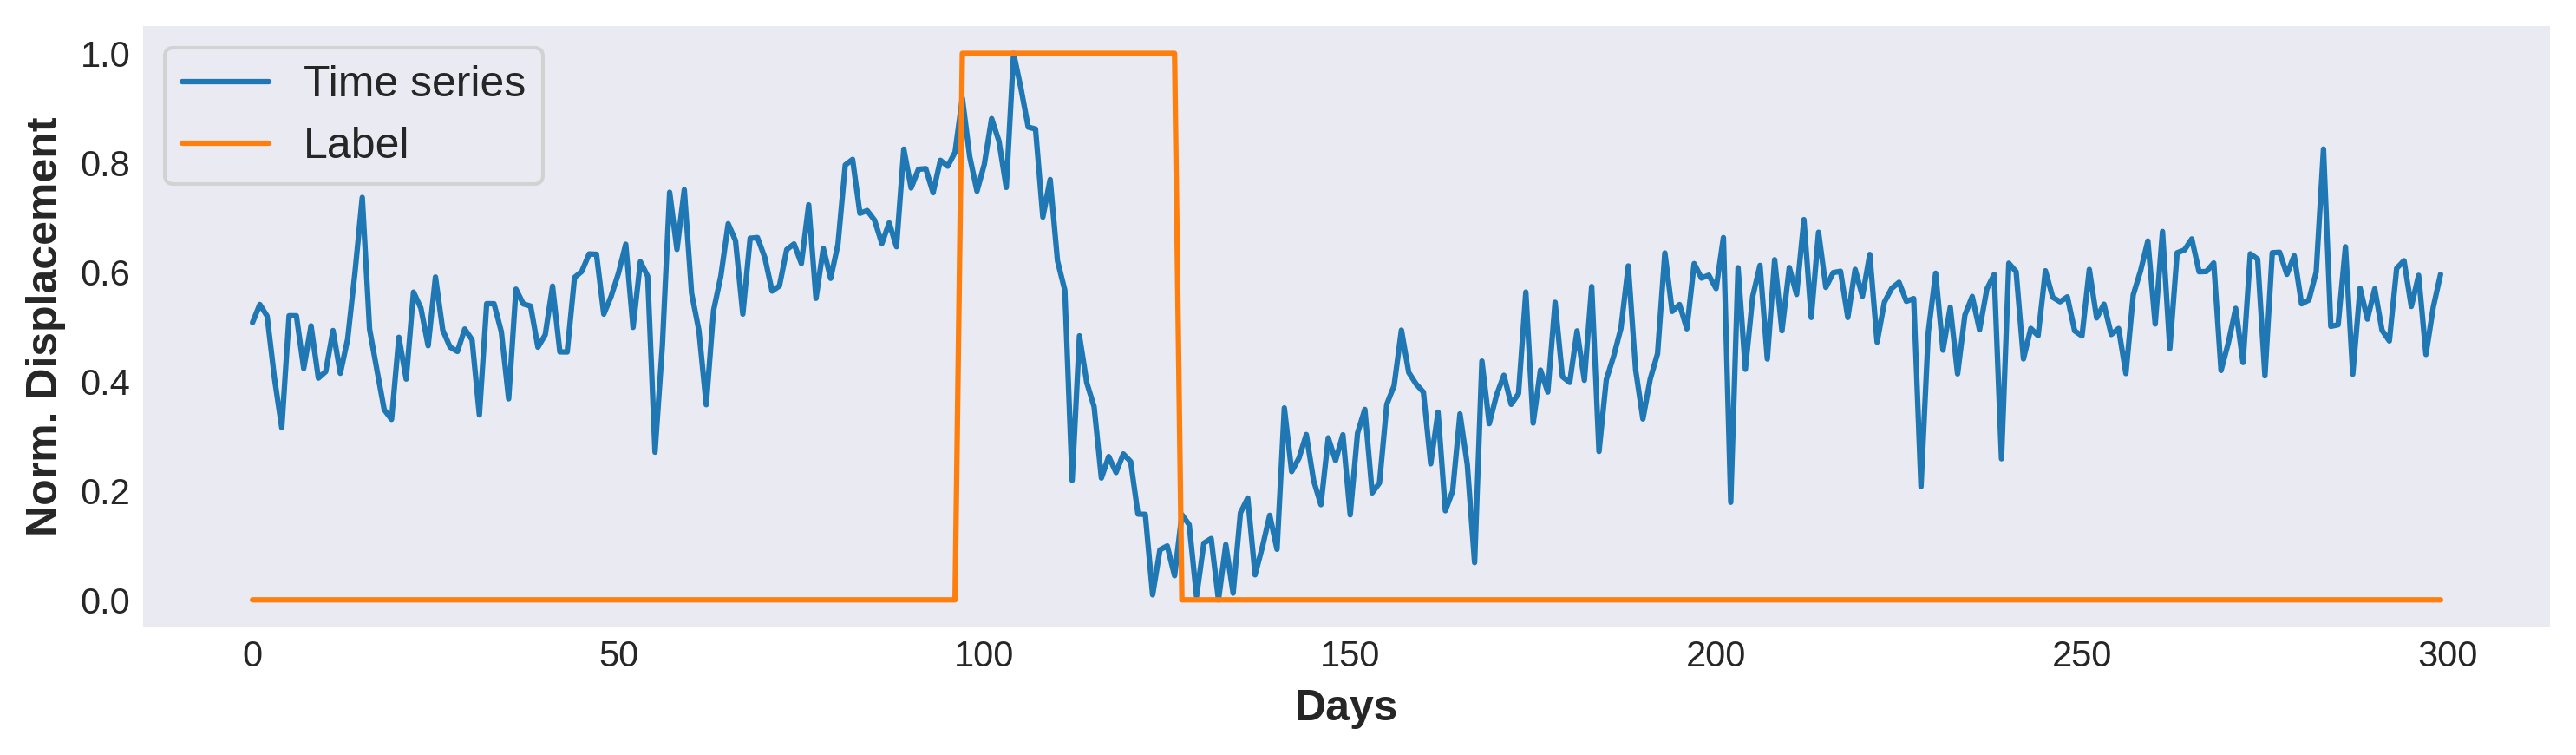

In [11]:
# Sample figure of synth data
i = 0
plt.figure(figsize=(10,3), dpi=300)
plt.plot(train_data[i,:], label='Time series')
plt.plot(train_label[i,:], label='Label')
plt.ylabel('Norm. Displacement', fontweight='bold', fontsize=12)
plt.xlabel('Days', fontweight='bold', fontsize=12)
plt.legend(fontsize=12, frameon=True)
plt.tight_layout()
plt.show()
#plt.savefig(img+'SSE_timeseries.png', dpi=300, transparent=True, format='png')

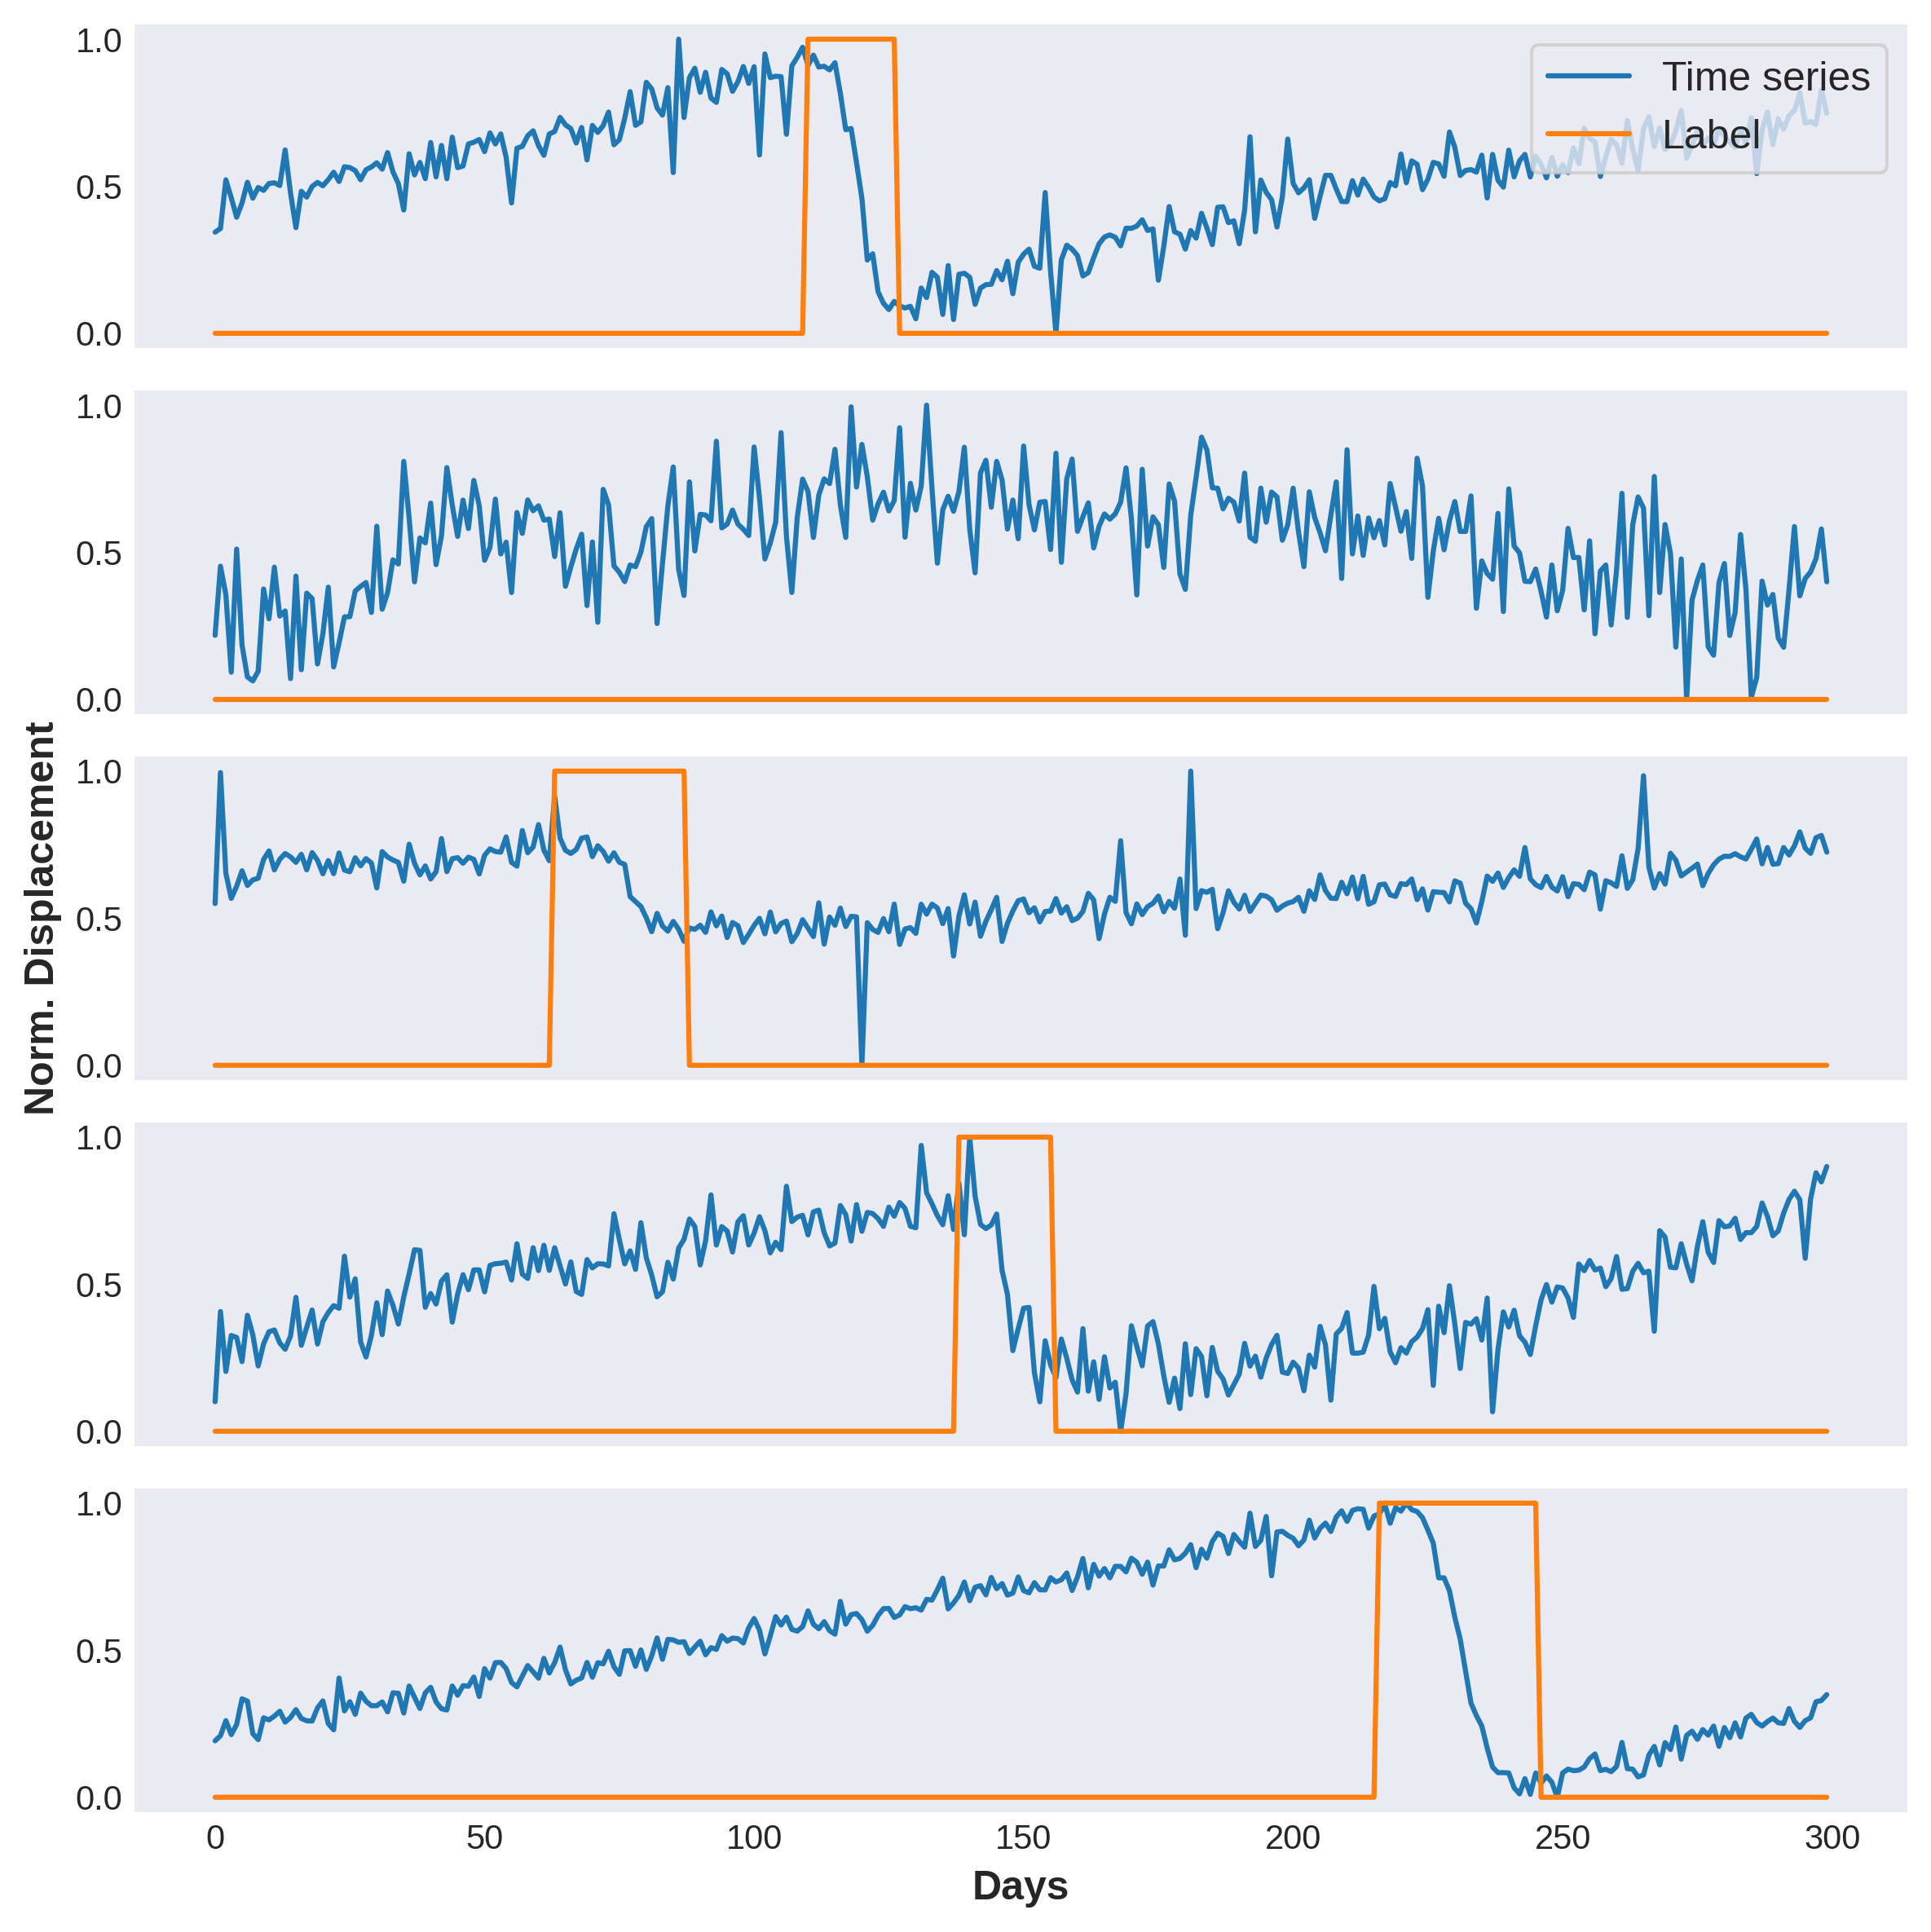

In [8]:
# Choose random examples for a figure
idxs = np.random.choice(n_train_sample, 5)

fig, axs = plt.subplots(5,1, figsize=(8,8), dpi=300, sharex=True)
c = 0
for i in idxs:
    axs[c].plot(train_data[i,:], label='Time series')
    axs[c].plot(train_label[i,:], label='Label')
    if c == 2:
        axs[c].set_ylabel('Norm. Displacement', fontweight='bold', fontsize=12)
    plt.xlabel('Days',fontweight='bold', fontsize=12)
    plt.tight_layout()
    if c == 0:
        axs[c].legend(fontsize=12, frameon=True, loc='upper right')
    c = c + 1
plt.show()
#plt.savefig(img+'random_timeseries.png', dpi=300, transparent=True, format='png')

## Optimal moving window?

In [9]:
# Possible windows to optimize
windows = np.arange(20,160,10)
#windows = np.arange(40,180,10)

# Preallocate performance results
train_acc = np.zeros(len(windows))
test_acc  = np.zeros(len(windows))
test_rec  = np.zeros(len(windows))

In [ ]:
# Delete memory-expensive features
settings = ComprehensiveFCParameters()
for ent in ['sample_entropy', 'approximate_entropy']:
    settings.pop(ent, None)

# Run for every window    
for j, window in enumerate(windows):
    print("_"*16)
    print('Window :',window)
    df_list = []  # List to hold DataFrames
    
    # Preallocate y array (targets)
    y = np.zeros(len(train_label), dtype=int)

    print("Slicing dataset")
    for i,label in enumerate(tqdm(train_label, mininterval=1)):
        ts = train_data[i,:]
        
        # DataFrame
        df_temp = pd.DataFrame(ts)
        df_temp['time'] = df_temp.index
        df_temp['id']   = i+1
        
        if 1.0 in label:
            # Position of SSE
            pos      = np.where(label == 1.0)[0]  # SSE positions
            center   = fn.NormalSelect(pos)       # Selects the center based on a normal distr. centered in the middle
            pos_ini  = center - window // 2 
            pos_stop = center + window // 2
            
            # Compensate window (if it goes out of range)
            if pos_ini < 0:
                pos_stop = pos_stop + abs(pos_ini)
                pos_ini  = 0
            if pos_stop > len(ts):
                pos_ini  = pos_ini + (len(ts)-pos_stop)
                pos_stop = len(ts)
        else:
            pos      = np.random.randint(low=window // 2, high=len(ts) - window // 2)
            pos_ini  = pos - window // 2
            pos_stop = pos + window // 2

        # Processed sample
        df_temp = df_temp.iloc[pos_ini:pos_stop]
        df_list.append(df_temp)  # Append DataFrame to list
        y[i] = 1 if 1.0 in label else 0  # Set target value
    
    # Concatenate DataFrames
    df = pd.concat(df_list, ignore_index=True)
    y  = pd.Series(y).astype(int)
    y.index = y.index + 1  # Make id coincide (0 -> 1)

    # --- Implementing new parallelization (joblib and batching) --- # 

    # Comment: With the update of tsfresh this is not necessary, now parallelization (built-in) works in all instances :)

    def extract_batch(df_batch):
        return extract_features(df_batch, column_id='id', column_sort='time',
                                default_fc_parameters=settings,
                                impute_function=impute,
                                n_jobs=0, show_warnings=False) # Parallel deactivated
    
    # Group ids into batches
    all_ids = df['id'].unique()
    batch_size = 500 # can increase if memory allows
    id_batches = [all_ids[i:i + batch_size] for i in range(0, len(all_ids), batch_size)]
    grouped_batches = [df[df['id'].isin(batch)] for batch in id_batches]

    print("Batched feature extraction")
    
    # Parallel feature extraction per batch
    features_list = Parallel(n_jobs=-1)(delayed(extract_batch)(g) for g in grouped_batches)
    df_extract = pd.concat(features_list)

    print("Features extracted... selecting features")

    # --- Back to old code --- #
    
    # Feature selection
    FDR_LEVEL  = 0.05
    df_extract = select_features(df_extract, y, chunksize=1, fdr_level=FDR_LEVEL)
    
    # Normalization
    index   = df_extract.index
    columns = df_extract.columns
    
    scaler     = StandardScaler()
    df_extract = pd.DataFrame(scaler.fit_transform(df_extract), index=index, columns=columns)
    
    X_train, X_test, y_train, y_test = train_test_split(df_extract, y, test_size=0.2, random_state=0)

    print("Training")
    
    # Clasification (dummy random forest)
    clf = ensemble.RandomForestClassifier(n_jobs=-1)
    clf.fit(X_train, y_train)
    print('Test accuracy:', clf.score(X_test, y_test))
    
    train_acc[j] = clf.score(X_train, y_train)
    test_acc[j]  = clf.score(X_test, y_test)
    test_rec[j]  = metrics.recall_score(y_test, clf.predict(X_test), average = 'macro')

In [4]:
# Save
#np.savetxt(prod+'optimal_window_accuracy.txt',test_acc)
#np.savetxt(prod+'optimal_window_recall.txt',test_rec)

# Load
windows  = np.arange(20,160,10)
test_acc = np.loadtxt(prod+'optimal_window_accuracy.txt')

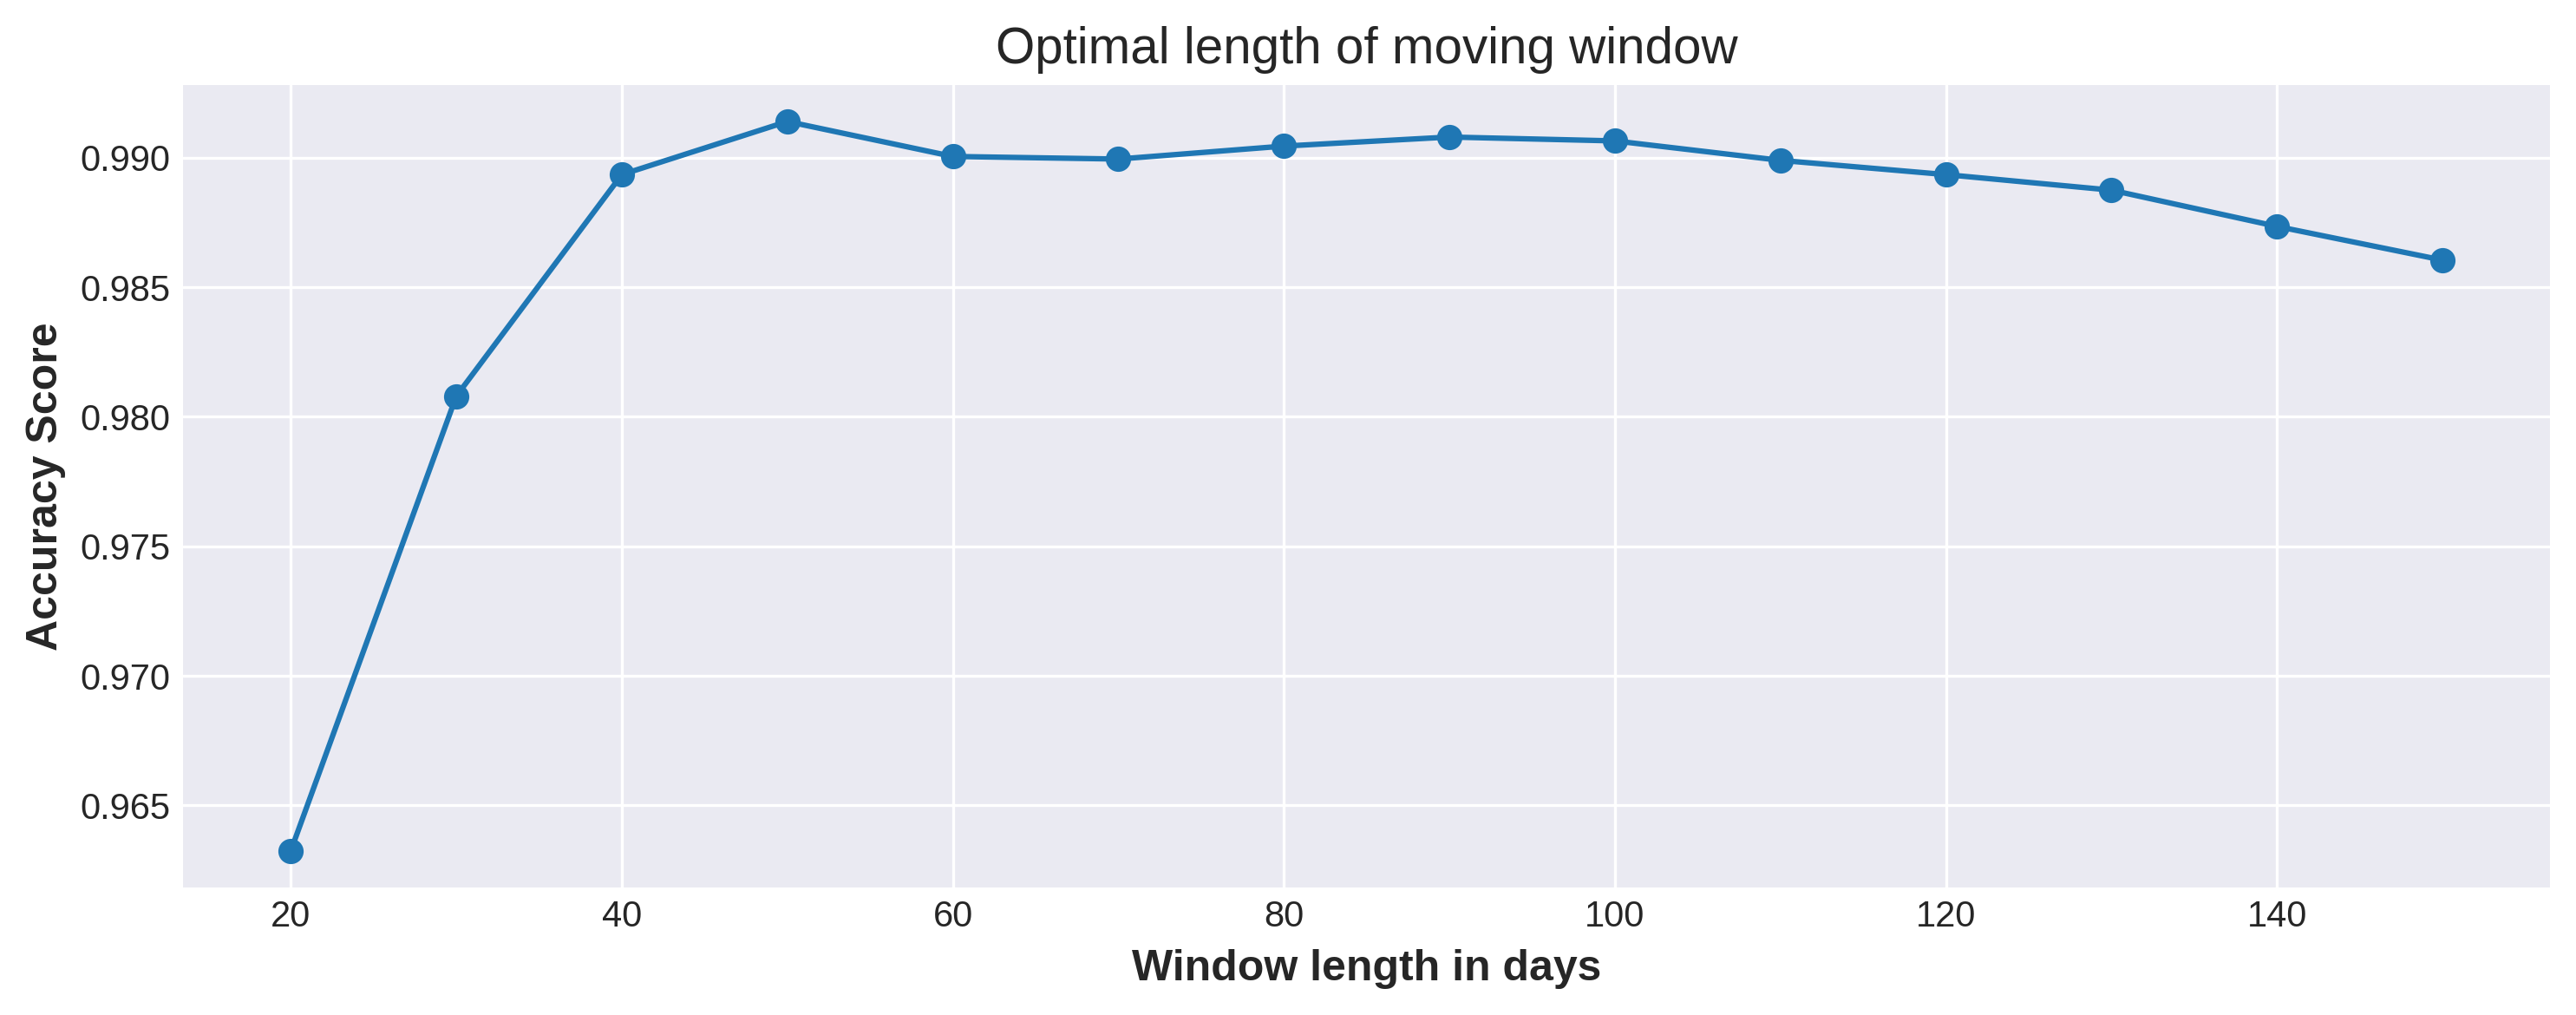

In [8]:
# Performance curve for selection of optimal window
plt.figure(figsize=(10,4), dpi=300)
plt.plot(windows, test_acc, marker='o')
plt.ylabel('Accuracy Score', fontweight='bold', fontsize=12) 
plt.xlabel('Window length in days', fontweight='bold', fontsize=12)
plt.title('Optimal length of moving window', fontsize=14)
plt.grid()
plt.tight_layout()
#plt.ylim([test_acc.min()-0.01,1])

plt.savefig(img + 'optimal_window.png', dpi=300, transparent=True, format='png')
plt.show()

## Feature extraction

In [16]:
# Window
window = windows[np.argmax(test_acc)]
print('Optimal window:', window)

Optimal window: 50


In [8]:
# Optimal window
window = 50

# Preallocate target array
y = np.zeros(len(train_label), dtype=int)

# List to hold DataFrames
df_list = []

print("Slicing dataset")

for i,label in enumerate(tqdm(train_label)):
    ts = train_data[i,:]
    
    # Create a DataFrame for the time series
    df_temp = pd.DataFrame(ts, columns=['value'])
    df_temp['time'] = df_temp.index
    df_temp['id']   = i + 1

    #--- Temp. added: Randomize window size ---#
    #window = np.random.randint(low=30, high=60)
    
    if 1.0 in label:
        # Position of SSE
        pos = np.where(label == 1.0)[0]  # Transient positions

        #--- Temp. added: SNR dependency for NormalSelect()
        #amp = np.max(ts[pos]) - np.min(ts[pos])
        #std = np.std(np.delete(ts, pos))  # crude noise estimate
        #snr = amp / (std + 1e-6)

        center = fn.NormalSelect(pos)    # Selects the center based on a normal distr. centered in the middle 
        
        pos_ini  = center - window // 2 
        pos_stop = center + window // 2
        
        # Compensate window
        if pos_ini < 0:
            pos_stop = pos_stop + abs(pos_ini)
            pos_ini  = 0
        if pos_stop > len(ts):
            pos_ini   = pos_ini+(len(ts)-pos_stop)
            post_stop = len(ts)
    else:
        pos      = np.random.randint(low=window // 2, high=len(ts) - window // 2)
        pos_ini  = pos - window // 2
        pos_stop = pos + window // 2

    df_temp = df_temp.iloc[pos_ini:pos_stop]
    df_list.append(df_temp)  # Append DataFrame to list
    y[i] = 1 if 1.0 in label else 0  # Set target value     

# Concatenate all DataFrames at once
df = pd.concat(df_list, ignore_index=True)

# Convert target values to a Pandas Series
y = pd.Series(y, dtype='int')
y.index = y.index + 1
    
# Remove entropy (memory heave feature)
settings = ComprehensiveFCParameters()
settings.pop('sample_entropy', None)
settings.pop('approximate_entropy', None)

def extract_batch(df_batch):
    return extract_features(df_batch, column_id='id', column_sort='time',
                            default_fc_parameters=settings,
                            impute_function=impute,
                            n_jobs=0, show_warnings=False)

# Group by IDs into batches
all_ids = df['id'].unique()
batch_size = 500  # Tune based on available memory
id_batches = [all_ids[i:i + batch_size] for i in range(0, len(all_ids), batch_size)]
grouped_batches = [df[df['id'].isin(batch)] for batch in id_batches]

print("Feature extraction")

# Parallel extraction across batches
features_list = Parallel(n_jobs=-1)(delayed(extract_batch)(g) for g in grouped_batches)
df_extract = pd.concat(features_list)

# === Final feature matrix ===
print(f"Feature matrix shape: {df_extract.shape}")

Slicing dataset


  0%|          | 0/100000 [00:00<?, ?it/s]

Feature extraction


Feature Extraction: 100%|██████████| 500/500 [01:28<00:00,  5.63it/s]


Feature matrix shape: (100000, 777)


## Feature selection

# Total 	 777
# Relevant 	 410
# Irrelevant 	 367 ( # Constant 0 )


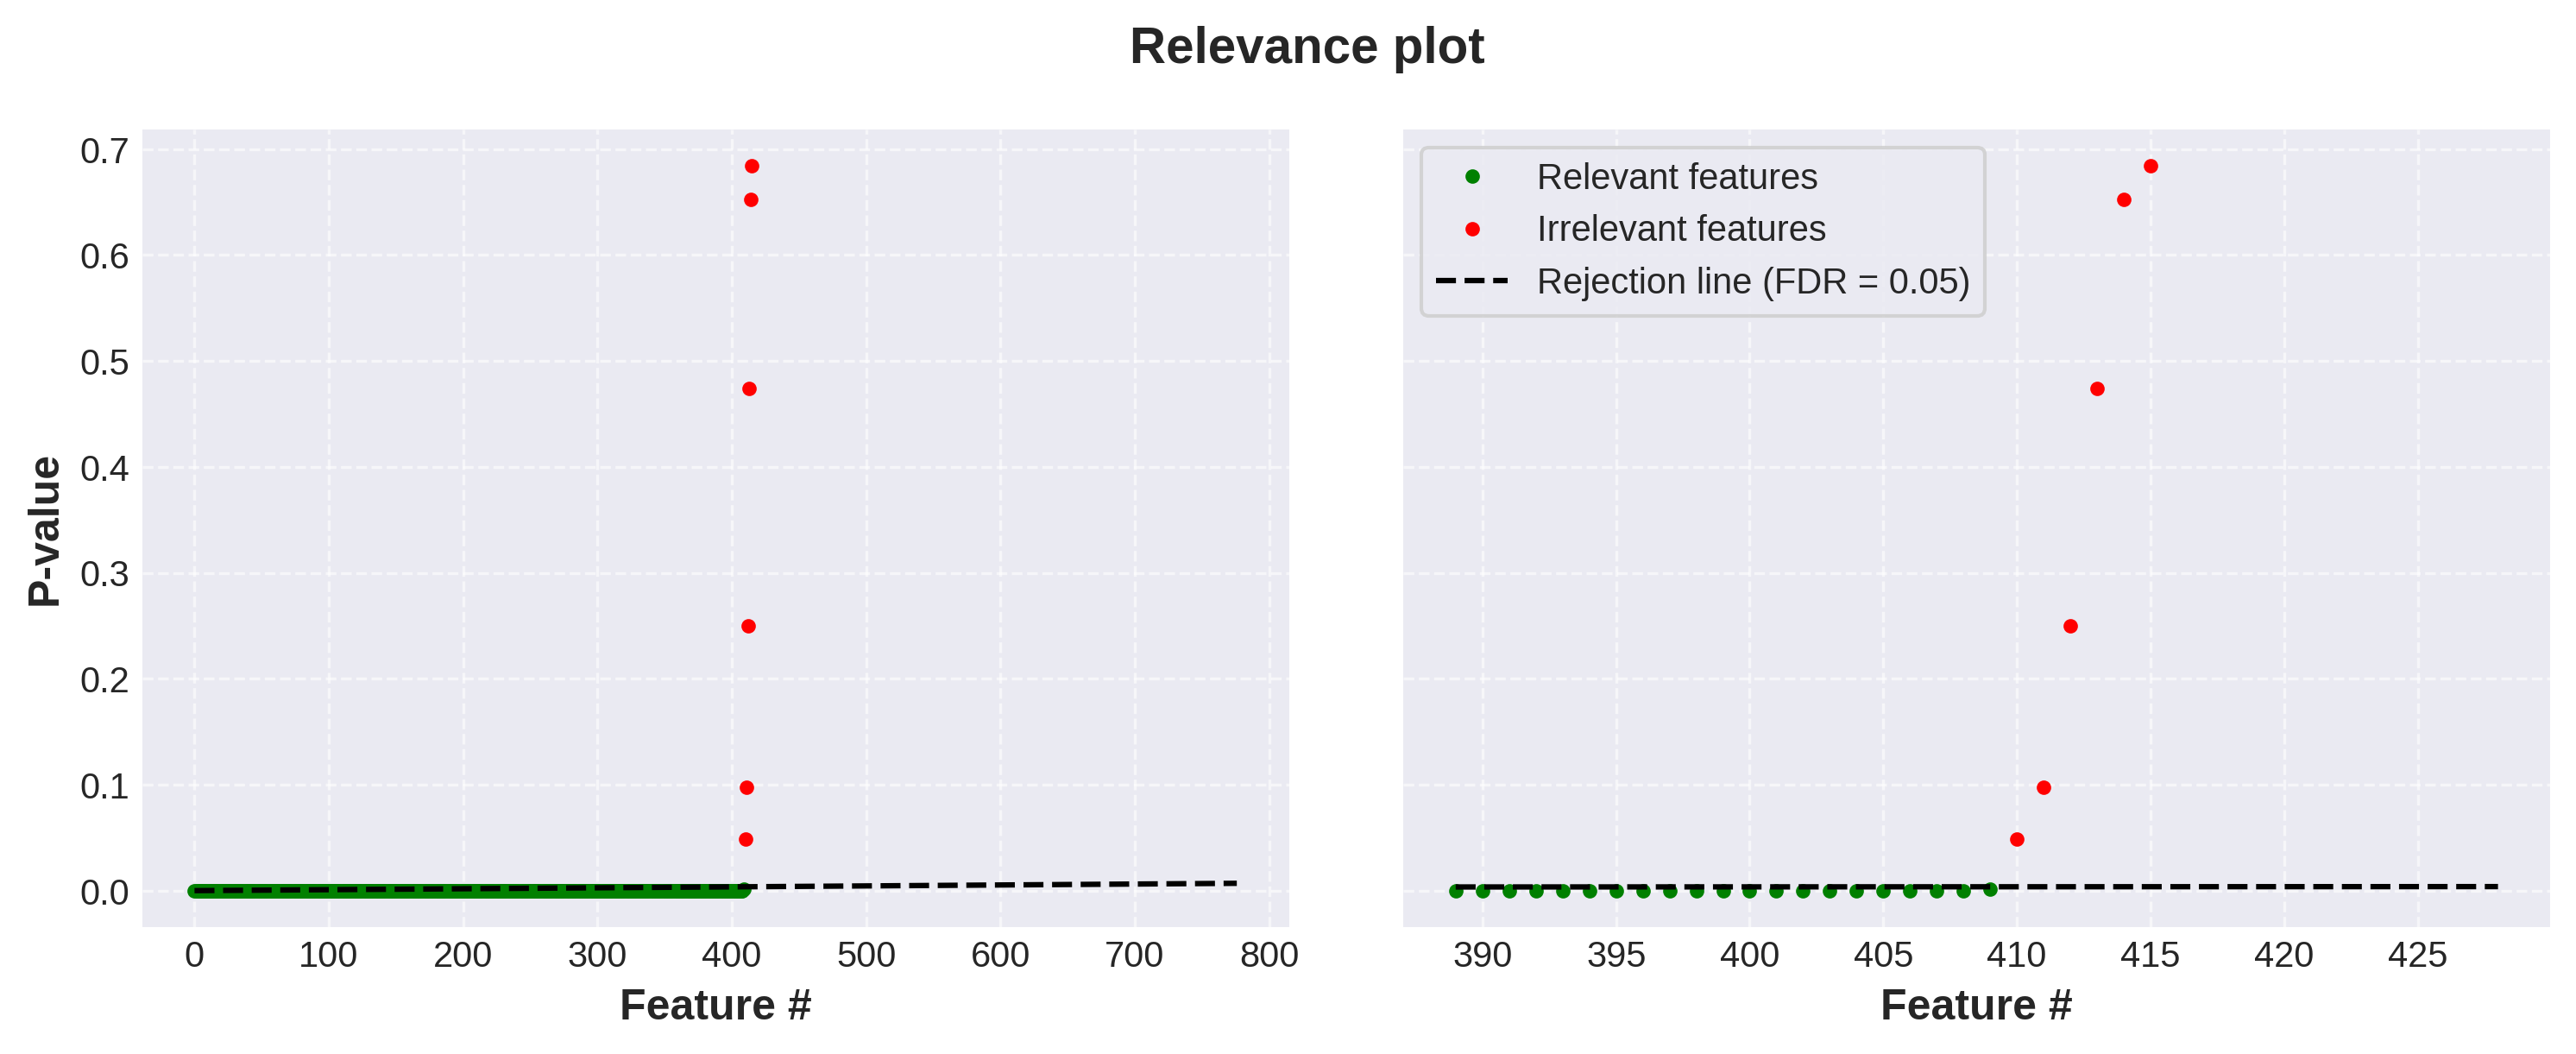

In [10]:
# Feature selection    
FDR_LEVEL = 0.05 

# Relevance
fn.RelevancePlot(df_extract, y, FDR=FDR_LEVEL)

plt.savefig(img + 'relevance_plot.png', dpi=300, transparent=True, format='png')
plt.show()

In [11]:
# Relevant features
df_extract = select_features(df_extract, y, chunksize=1, fdr_level=FDR_LEVEL)

# Save features selected during the extraction 
kind_to_fc_parameters = from_columns(df_extract) 

# Scaling of features
index   = df_extract.index
columns = df_extract.columns

scaler = StandardScaler()
scaler.fit(df_extract)
df_extract = scaler.transform(df_extract)
df_extract = pd.DataFrame(df_extract, index=index, columns=columns) 

Guardado de variables

In [12]:
df_extract.to_hdf(prod+'tsfresh_data.h5',key='key',complevel=9) # Already scaled feature frame
y.to_hdf(prod+'tsfresh_label.h5', key='key', complevel=9) # Target values for feature frame

file = open(prod+'settings_tsfresh.pkl', 'wb') # Save settings for tsfresh
pickle.dump(kind_to_fc_parameters,file)
file.close()
 
file = open(prod+'settings_scaler.pkl', 'wb') # Save fitted scaler
pickle.dump(scaler, file)
file.close()

Carga de variables

In [13]:
df_extract = pd.read_hdf(prod+'tsfresh_data.h5',key='key')
names = df_extract.columns # Features names (maintain order)

y = pd.read_hdf(prod+'tsfresh_label.h5', key='key') 

# Split training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df_extract, y, test_size=0.2, random_state=0) 

file = open(prod+'settings_tsfresh.pkl', 'rb')
settings = pickle.load(file)
file.close()

file = open(prod+'settings_scaler.pkl', 'rb')
scaler = pickle.load(file)
file.close()

## Prunning

Number of alpha values: 245


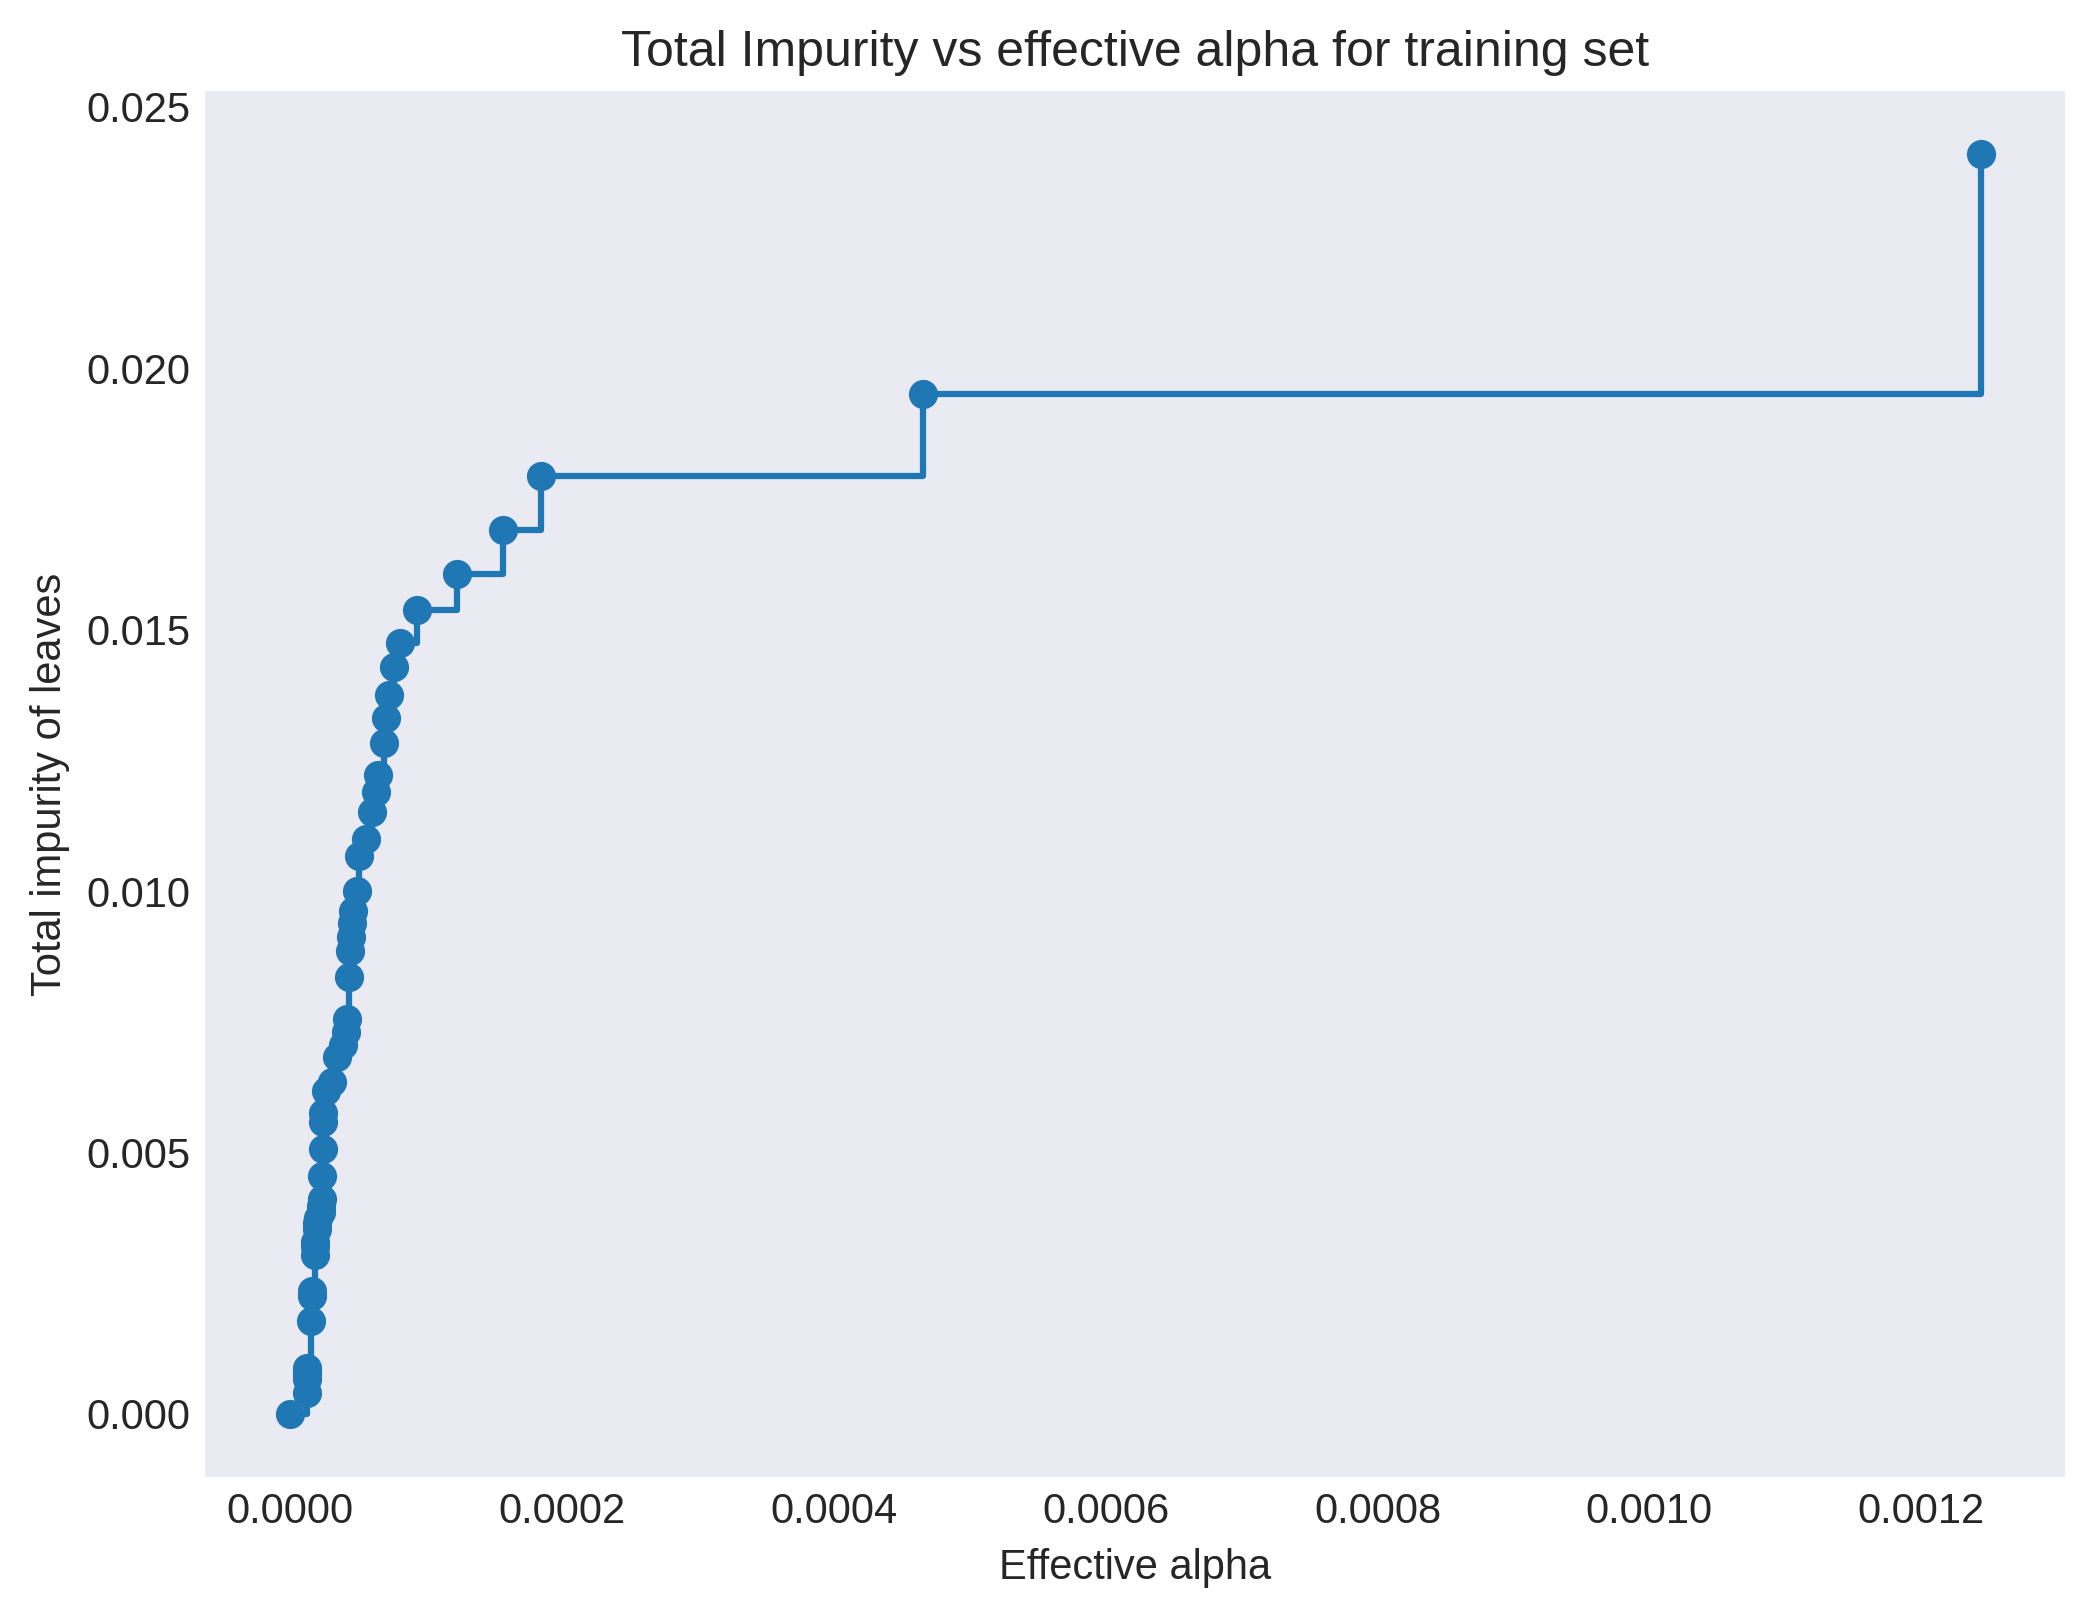

  0%|          | 0/50 [00:00<?, ?it/s]

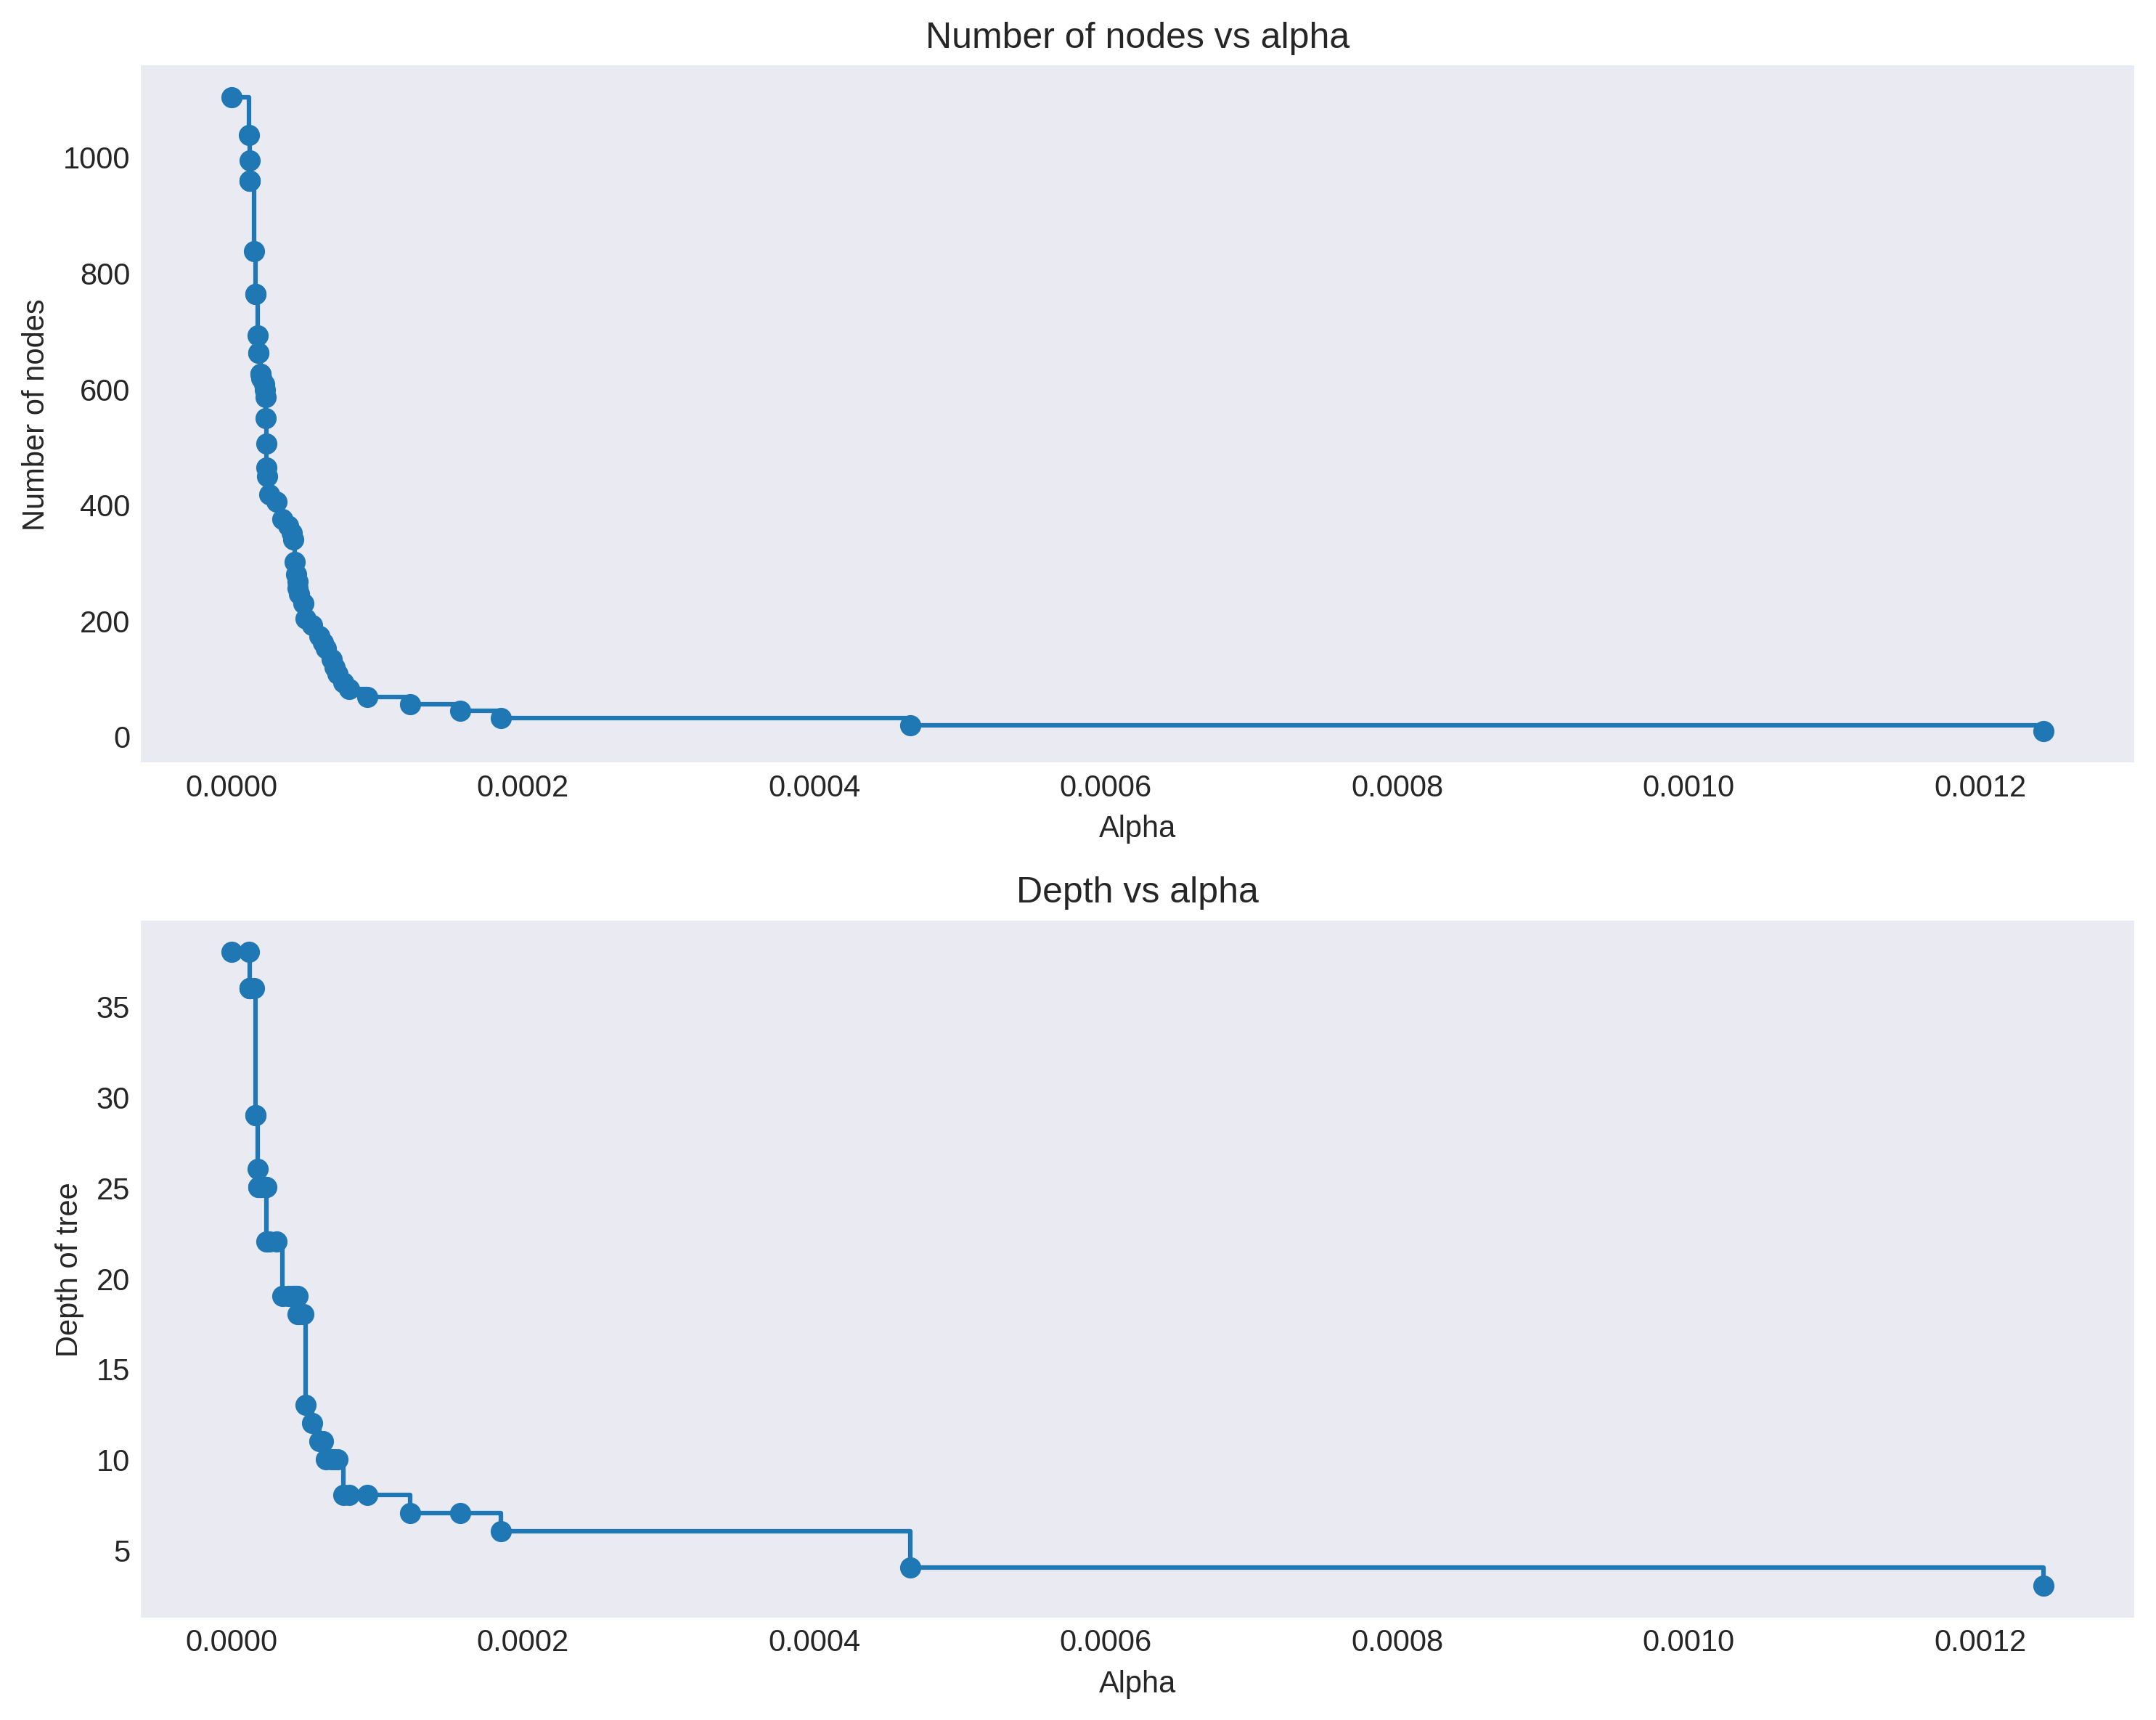

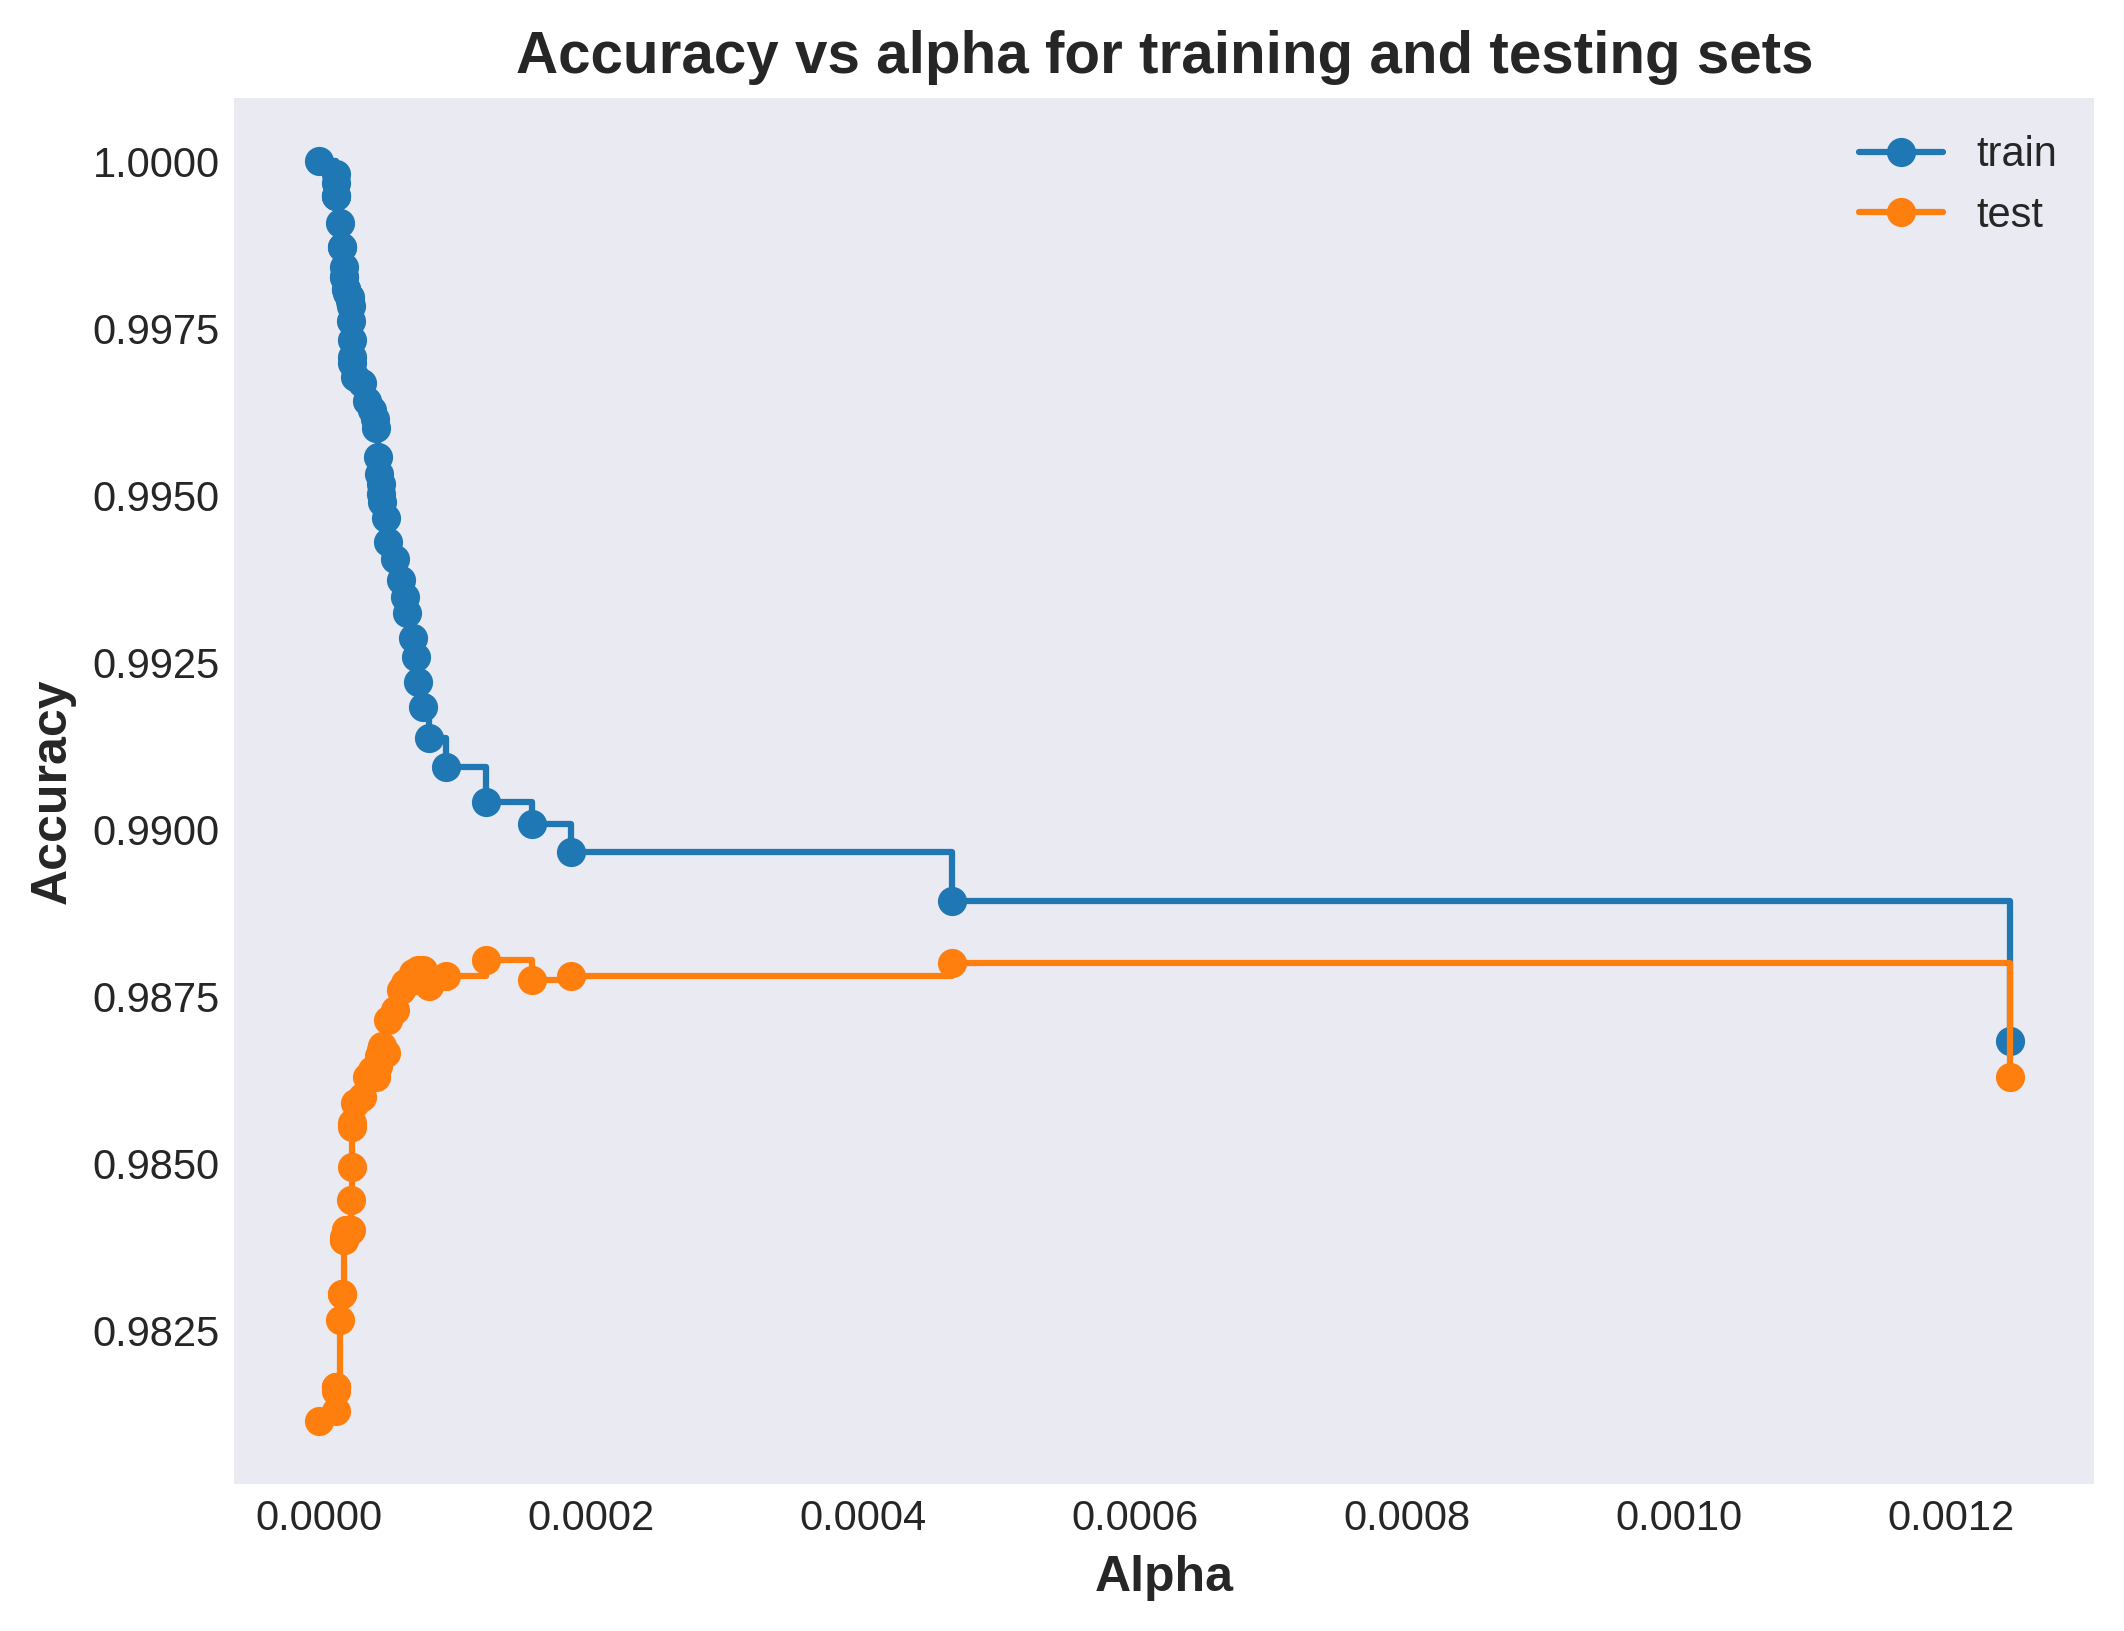

Best alpha value: 0.00012267141188097928


In [14]:
# Estimation of pruning param for tree algorithms
ccp_alpha = fn.CostComplexityPruning(X_train, y_train, X_test, y_test)

## Diagram testing

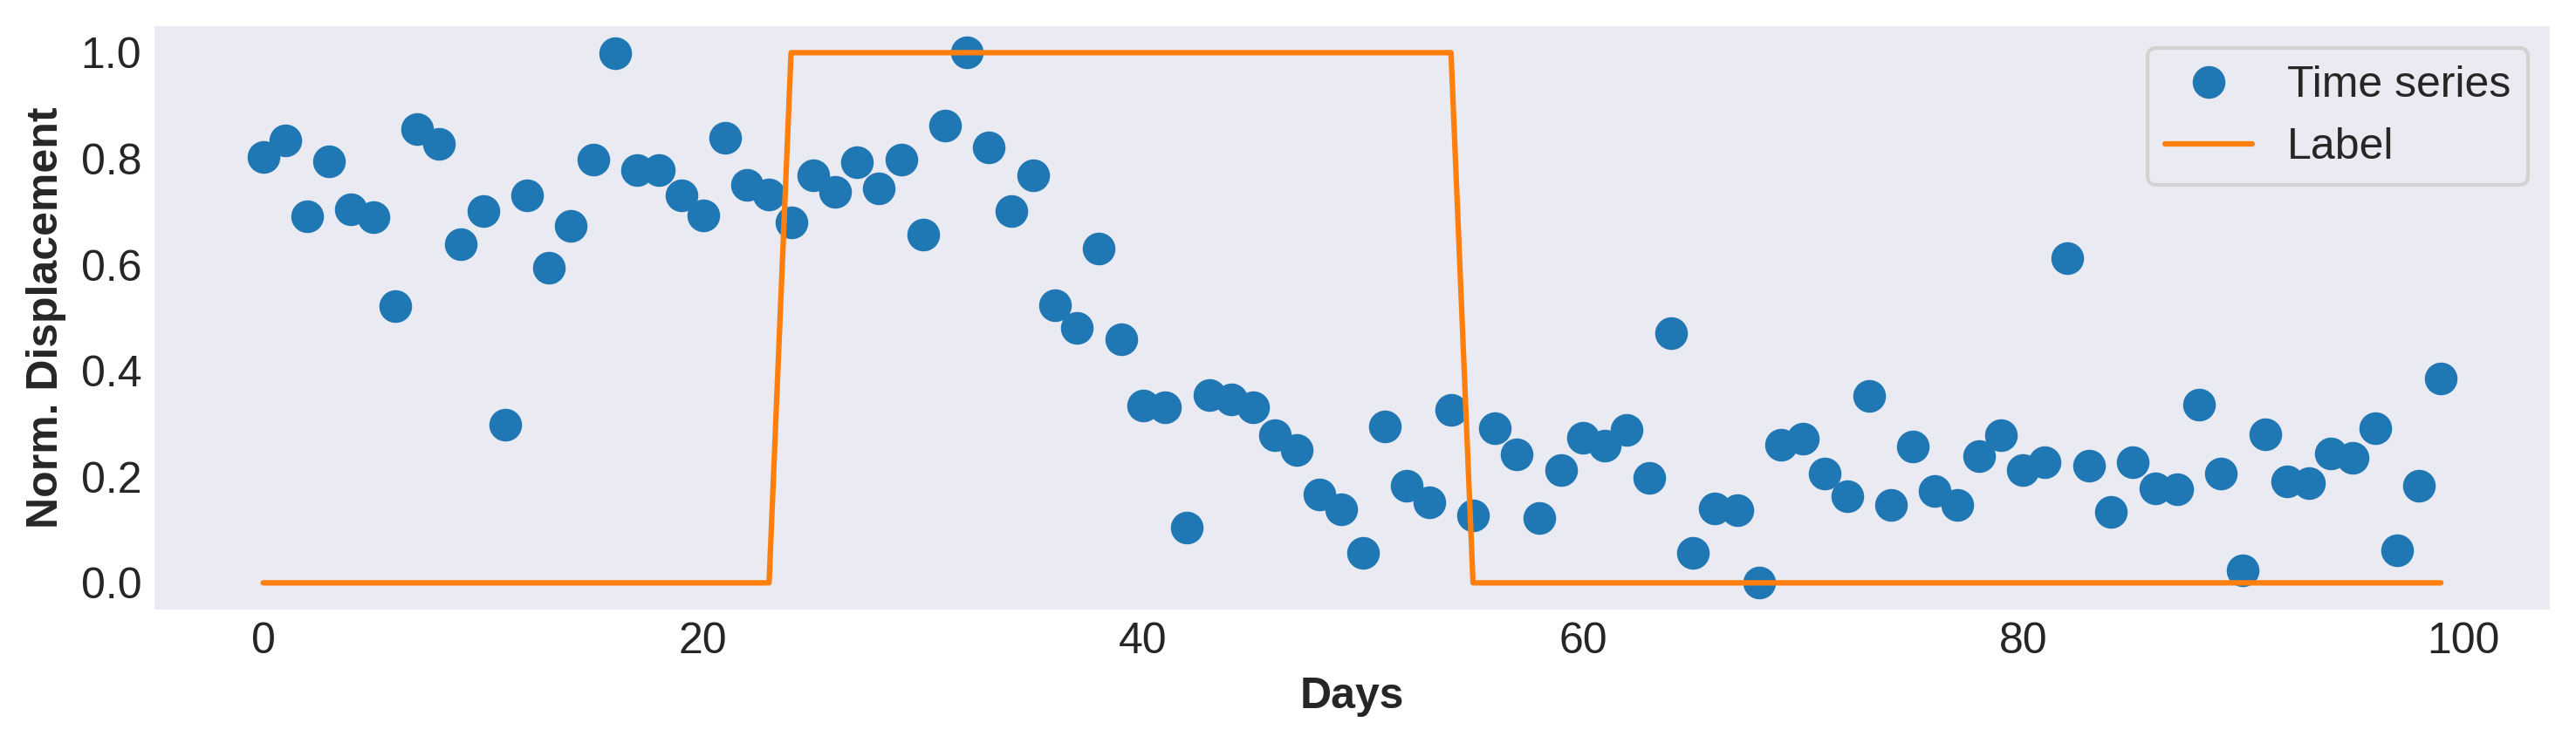

In [12]:
# Use the same figure as before as reference
i = 0
plt.figure(figsize=(10,3), dpi=300)
plt.plot(train_data[i,:100], 'o', markersize=8, label='Time series')
plt.plot(train_label[i,:100], label='Label')
plt.ylabel('Norm. Displacement', fontweight='bold', fontsize=12)
plt.xlabel('Days', fontweight='bold', fontsize=12)
plt.legend(fontsize=12, frameon=True)
plt.tight_layout()
plt.show()

In [20]:
# Redefine
ts_data  = train_data[i,:100]
ts_label = train_label[i,:100]

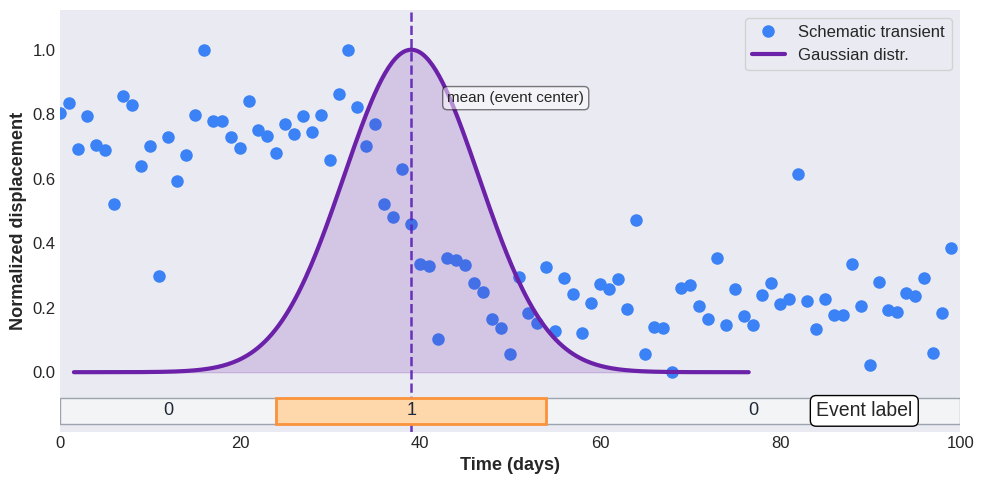

In [55]:
from matplotlib.patches import Rectangle
from scipy.ndimage import gaussian_filter1d

n_points = len(ts_data)
t        = np.linspace(0, n_points)

# map event times to indices
idx = np.arange(n_points)
event_indices = np.where(ts_label==1.0)[0]

event_start = event_indices[0] 
event_end   = event_indices[-1]

# compute mean and sigma (in 't' units)
mean_t  = (event_start + event_end) / 2.0

half_duration = (event_end - event_start) / 2.0
sigma_t = half_duration / 2.0 # The gaussian is 2-sigma in the edge

# build gaussian curve used for window selection (scaled down for plotting)
gauss_x = np.linspace(event_start - 1.5*half_duration, event_end + 1.5*half_duration, 400)
gauss = np.exp(-0.5 * ((gauss_x - mean_t) / sigma_t)**2)

# sample randomized centers from Normal(mean, sigma)
random_centers = rng.normal(loc=mean_t, scale=sigma_t, size=n_random_centers)
# optionally clip them so they are not wildly outside the series (visual choice)
random_centers = np.clip(random_centers, t.min(), t.max())

# ------- Plotting -------
plt.rcParams.update({
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, ax = plt.subplots(figsize=(10, 5))

# plot schematic transient (blue)
ax.plot(ts_data, 'o', markersize=8, label='Schematic transient', color='#3b82f6', zorder=1)
#ax.plot(ts_label)

# plot gaussian (purple) and fill under it
ax.plot(gauss_x, gauss, linewidth=3.0, color='#6b21a8', label='Gaussian distr.')
ax.fill_between(gauss_x, gauss, alpha=0.18, color='#6b21a8')

# dashed vertical line for the event mean
ax.axvline(mean_t, linestyle='--', linewidth=1.8, color='#5b21b6', alpha=0.9)
ax.text(mean_t + 4, gauss.max()*0.85, 'mean (event center)',
        va='center', fontsize=11, bbox = {'boxstyle': 'round', 'facecolor':'white', 'alpha':0.5})

# draw the event label as an orange rectangle (one contiguous block of ones)
label_rect_x      = event_start_time
label_rect_y      = baseline_y - 0.04
label_rect_width  = event_end_time - event_start_time
label_rect_height = 0.08

# Left region (label=0)
rect_left = Rectangle((t.min(), label_rect_y),
                      event_start, label_rect_height,
                      linewidth=1.0, edgecolor='#9ca3af', facecolor='#f3f4f6', zorder=2)
ax.add_patch(rect_left)
ax.text(t.min() + event_start/2, label_rect_y + label_rect_height*0.5, '0',
        ha='center', va='center', fontsize=13, color='#1f2937')

# Event region (label=1, orange)
rect_event = Rectangle((event_start, label_rect_y),
                       event_end - event_start, label_rect_height,
                       linewidth=2.0, edgecolor='#fb923c', facecolor='#fed7aa', zorder=3)
ax.add_patch(rect_event)
ax.text((event_start + event_end)/2, label_rect_y + label_rect_height*0.5, '1',
        ha='center', va='center', fontsize=13, color='#1f2937')

# Right region (label=0)
rect_right = Rectangle((event_end, label_rect_y),
                       t.max() - event_end, label_rect_height,
                       linewidth=1.0, edgecolor='#9ca3af', facecolor='#f3f4f6', zorder=2)
ax.add_patch(rect_right)
ax.text(event_end + (t.max()-event_end)/2, label_rect_y + label_rect_height*0.5, '0',
        ha='center', va='center', fontsize=13, color='#1f2937')

# Move "Event label" text to the right of the event block
ax.text(event_end + 30,
        label_rect_y + label_rect_height*0.5,
        'Event label', fontsize=14, va='center',
        bbox={'boxstyle': 'round', 'facecolor':'white'})

# fluff: axis labels, limits and legend
ax.set_xlabel('Time (days)', fontsize=13, fontweight='bold')
ax.set_ylabel('Normalized displacement', fontsize=13, fontweight='bold')
ax.set_xlim(t.min(), t.max())
ax.set_ylim(baseline_y - 0.06*transient.max(), 1.05*transient.max())

# tighten & legend
ax.legend(frameon=True, loc='upper right')
plt.tight_layout()
plt.savefig(img + 'paper_diagram.png', dpi=600, transparent=True, format='png')
plt.show()